<a href="https://colab.research.google.com/github/princedanson/Intermidiate_1/blob/main/tutorials/contact_4/Question_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [379]:
import pandas as pd
import numpy as np
from sklearn.linear_model import (LinearRegression,Ridge,Lasso,ElasticNet)
from sklearn.preprocessing import (PolynomialFeatures, StandardScaler,PowerTransformer)
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (mean_absolute_error,mean_squared_error,
                             root_mean_squared_error,accuracy_score,r2_score)
# NOTE: The error 'ValueError: Found input variables with inconsistent numbers of samples' is not in this cell.
# It arises because x_train_scaled and y_train have different numbers of samples after outlier removal.
# To fix this, you need to modify cell 'RhJJMmfMLr7L' to also filter y_train and y_test.
# Please refer to the explanation above for the correct code to update cell 'RhJJMmfMLr7L'.

In [380]:
boston = fetch_openml(name='boston', version=1,as_frame=False)

In [381]:
df = pd.DataFrame(boston.data, columns=boston.feature_names)
df['MEDV'] = boston.target


In [382]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.09,1,296.0,15.3,396.9,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.9,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.9,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.12,76.7,2.2875,1,273.0,21.0,396.9,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.9,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [383]:
x =df.drop(['MEDV'], axis = 1)
y = df['MEDV']

In [384]:
x.skew()

,0
CRIM,5.223149
ZN,2.225666
INDUS,0.295022
CHAS,3.405904
NOX,0.729308
RM,0.403612
AGE,-0.598963
DIS,1.011781
RAD,1.004815
TAX,0.669956


In [385]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [386]:
colunms_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT']

In [387]:
transformer = PowerTransformer(method='yeo-johnson')
x_train_transform= transformer.fit_transform(x_train[colunms_names])
x_test_transform = transformer.transform(x_test[colunms_names])

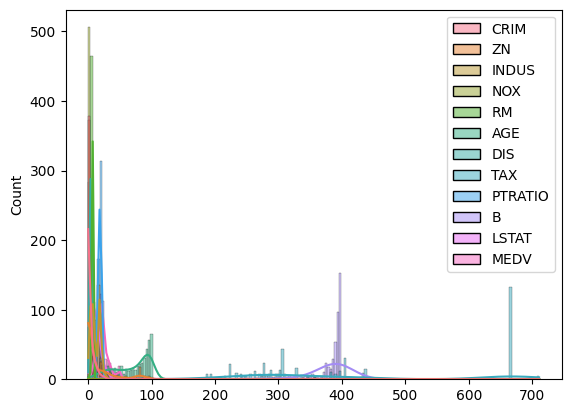

In [388]:
sns.histplot(df, kde=True)
plt.show()

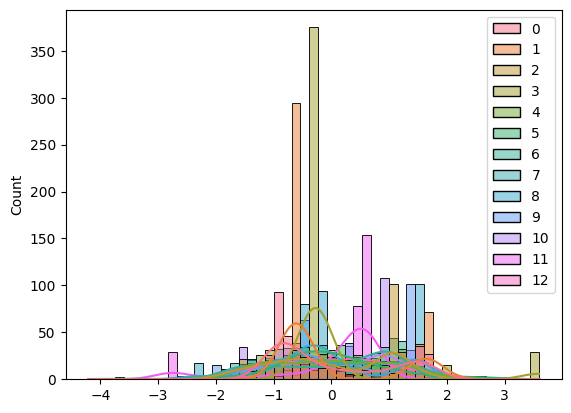

In [389]:
sns.histplot(x_train_transform, kde=True)
plt.show()

In [390]:
x_train_transform

array([[ 1.63241784, -0.61143074,  1.02590994, ...,  0.87993863,
        -0.66036566,  1.51915974],
       [ 0.00589163, -0.61143074, -0.22019836, ...,  1.42975162,
         0.5948799 , -0.42209432],
       [-0.98991095,  1.64526707, -0.58939831, ..., -0.79900945,
        -0.35482168, -0.54827285],
       ...,
       [-1.04236674,  1.69862748, -1.605928  , ..., -0.76022265,
         0.44762642, -0.96180689],
       [ 1.57057069, -0.61143074,  1.02590994, ...,  0.87993863,
        -2.7598785 ,  1.38556565],
       [-0.56025693, -0.61143074, -0.15266118, ...,  1.35755321,
        -2.78272439, -0.04522594]])

In [391]:

threshold = 3

# Create masks for outlier removal
train_mask = (np.abs(x_train_transform) < threshold).all(axis=1)
test_mask = (np.abs(x_test_transform) < threshold).all(axis=1)

# Apply masks to x_transform and y
x_train_transform = x_train_transform[train_mask]
y_train = y_train[train_mask] # Filter y_train

x_test_transform = x_test_transform[test_mask]
y_test = y_test[test_mask] # Filter y_test

print(x_train_transform.shape)
print(x_test_transform.shape)
print(y_train.shape)
print(y_test.shape)


print(x_train_transform.shape)
print(x_test_transform.shape)


(370, 13)
(95, 13)
(370,)
(95,)
(370, 13)
(95, 13)


In [392]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_transform)
x_test_scaled = scaler.fit_transform(x_test_transform)

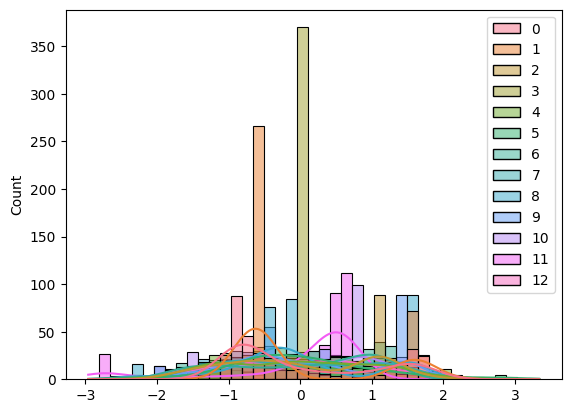

In [393]:
sns.histplot(x_train_scaled, kde=True)
plt.show()

In [394]:
x_train_scaled.reshape(-1,1)

array([[ 1.67682483],
       [-0.62502319],
       [ 1.05983039],
       ...,
       [ 1.33363036],
       [-2.76420732],
       [-0.05829069]])

**Modelling**

In [395]:
#model = LinearRegression()
#model = Ridge(alpha=0.1)
#model = Lasso(alpha=0.1)
model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(x_train_scaled,y_train)

ElasticNet(alpha=0.1)

In [396]:
pred = model.predict(x_test_scaled)

**Matrices Evaluations**

In [397]:
df.describe()

,MEDV
count,506.000000
mean,22.532806
std,9.197104
min,5.000000
25%,17.025000
50%,21.200000
75%,25.000000
max,50.000000


In [405]:
adjusted_r2 = 1-(1-r2_score(y_test,pred))*(len(y_test)-1)/(len(y_test)-x_test_scaled.shape[1]-1)
residual = y_test - pred
print(f'coefficient of determination(Traning R2 Score): {model.score(x_train_scaled,y_train)}')
print(f'Testing R2 Score: {model.score(x_test_scaled,y_test)}')
#print(f'Test r2 score: {r2_score(y_test,pred)}')
print(f'intercept: {model.intercept_}')
print(f'coefficient: {model.coef_}')
print(f'mean squared error: {mean_squared_error(y_test,pred)}')
print(f'root mean squared error: {np.sqrt(mean_squared_error(y_test,pred))}')
print(f'mean absolute error: {mean_absolute_error(y_test,pred)}')
print(f'adjusted r2 score: {adjusted_r2}')
print(f'residual:\n {residual}')
print(f'baseline : {y_train.mean()}')


coefficient of determination(Traning R2 Score): 0.7840086748423136
Testing R2 Score: 0.7080695706041296
intercept: 22.31297297297297
coefficient: [-0.          0.         -0.27381401  0.         -0.17494844  2.60482942
 -0.05436948 -1.68024788  0.36642754 -1.39427325 -1.60301549  0.68268898
 -4.18416308]
mean squared error: 22.280475189041567
root mean squared error: 4.720219824228694
mean absolute error: 3.2927967376521243
adjusted r2 score: 0.66121653872578
residual:
 173    -6.226589
491    -3.202830
72     -4.043187
452    -2.376349
76     -2.367353
         ...    
412    13.567641
436    -7.677126
411    -0.621536
86     -0.586521
75     -2.988892
Name: MEDV, Length: 95, dtype: float64
baseline : 22.31297297297297


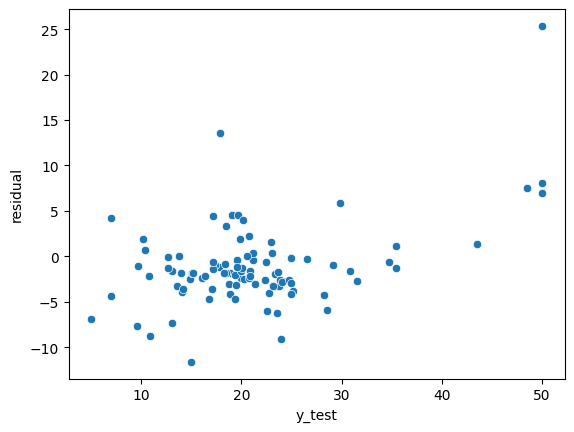

In [400]:
sns.scatterplot(x=y_test,y=residual)
plt.xlabel('y_test')
plt.ylabel('residual')
plt.show()